In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def compute_spectra(bins, v, ndft):
    sfdr = np.zeros(len(bins))
    hd3 = np.zeros(len(bins))
    spec_dbv_out = np.zeros((len(bins), ndft//2+1))
    for i in bins:
        y = v[i-1, :]
        y = y[:-1]
        relative_error = (y[-1]-y[-1-ndft])/y[-1]
        print(relative_error)
        y = y[-ndft:]
        spec = np.fft.rfft(y)
        spec_dbv = 20*np.log10(np.abs(spec)/(ndft/2))
        spec_dbv_out[i-1, :] = spec_dbv
        sfdr[i-1] = spec_dbv[i] - np.max(np.delete(spec_dbv, [0, i]))
        hd3[i-1] = spec_dbv[i] - spec_dbv[get_third_harmonic_bin(i, ndft)]
    return sfdr, hd3, spec_dbv_out

In [3]:
def get_third_harmonic_bin(i, ndft):
    """
    Finds the 3rd harmonic bin for a real-valued signal.
    i: fundamental bin index
    nfft: total number of FFT points
    """
    # Step 1: Wrap around the sampling frequency
    wrapped_bin = (3 * i) % ndft
    
    # Step 2: Fold back if it's above Nyquist
    if wrapped_bin > ndft // 2:
        harmonic_bin = ndft - wrapped_bin
    else:
        harmonic_bin = wrapped_bin
        
    return int(harmonic_bin)

In [4]:
df1 = pd.read_csv('./xschem/simulation/tb_boot_bottom_4.txt', sep='\\s+')
df1

,time,v(vi),v(vo)
0,1.900000e-09,0.657401,0.631111
1,3.900000e-09,0.715500,0.690502
2,5.900000e-09,0.768870,0.746205
3,7.900000e-09,0.815327,0.795926
4,9.900000e-09,0.852968,0.837634
...,...,...,...
535,6.390000e-08,0.675304,0.898626
536,6.590000e-08,0.495701,0.302890
537,6.790000e-08,0.732216,0.891576
538,6.990000e-08,0.441212,0.315575


In [5]:
# Parameters
fs = 500e6
ndft = 31
runs = 15
bins = np.arange(1, runs+1)

In [6]:
vi = np.reshape(df1['v(vi)'].values, [runs, len(df1)//runs])
vo = np.reshape(df1['v(vo)'].values, [runs, len(df1)//runs])

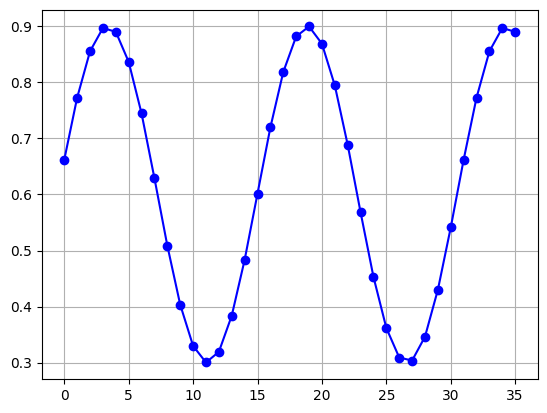

In [7]:
plt.plot(vo[1, :], "b-o")
plt.grid()
plt.show()

In [8]:
hd3_vi = compute_spectra(bins, vi, ndft)[1]
hd3_vo = compute_spectra(bins, vo, ndft)[1]

-6.500460399995625e-09
-3.3338448130606757e-10
-1.3711314084465617e-09
-1.7188019767926338e-10
-9.39850951512751e-09
-1.840044610657577e-06
2.626623104147727e-07
8.203262188946e-08
1.0726558170229835e-09
-7.91925970816926e-09
-1.7960243460251808e-08
-2.7489082776843776e-08
-5.310934209630981e-06
3.2443211554091294e-06
2.584926006095162e-06
-1.8310780416608085e-06
-2.7065912600013115e-07
-6.578020873367731e-06
-6.582198517365226e-07
2.3218895005471804e-05
3.3934123844666614e-06
5.30246655053929e-07
6.1586185216051885e-06
4.085550104131372e-06
2.3594546752137856e-06
-8.575748271524777e-07
-4.622235810529275e-06
1.1503468834324307e-05
-0.00010203663794286853
-1.0201701615537739e-05


In [9]:
# Analysis
vdd = 1.2
vt = 0.47
cpss = 0
cpls = 55e-15
cb = 830e-15
cpss = cb/10
vgs = vdd*cb/(cb+cpls)
vov = vgs - vt
print(vov)
vm = 0.3
fs = 500e6
fin = bins*fs/ndft
fbw= 6.6e9
hd3_calc = -20*np.log10((1/2)*fin/fbw*(vm/vov)**2 *(cpss/cb+0.11)**2)
print(fbw/1e6)

0.6554237288135594
6600.0


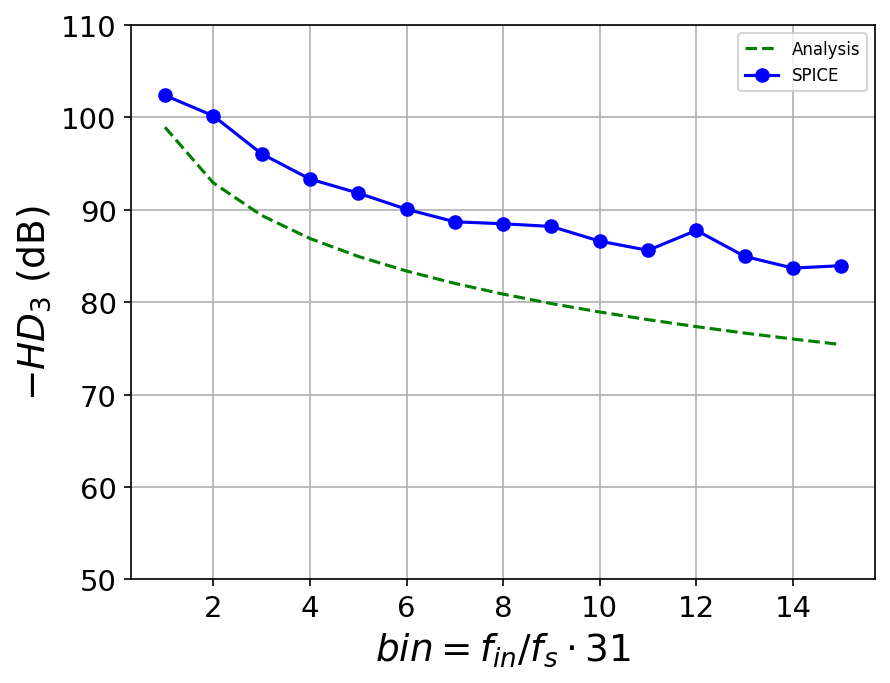

In [10]:
plt.rcParams['figure.dpi'] = 150
plt.plot(bins, hd3_calc, "g--", label='Analysis')
#plt.plot(bins, hd3_vi, "r--", label='vi hold')
plt.plot(bins, hd3_vo, "b-o", label='SPICE')
    
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("$-HD_3$ (dB)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(50, 110)
plt.grid(True)
plt.legend(fontsize=8)
plt.show()

-1.8310780416608085e-06
-2.7065912600013115e-07
-6.578020873367731e-06
-6.582198517365226e-07
2.3218895005471804e-05
3.3934123844666614e-06
5.30246655053929e-07
6.1586185216051885e-06
4.085550104131372e-06
2.3594546752137856e-06
-8.575748271524777e-07
-4.622235810529275e-06
1.1503468834324307e-05
-0.00010203663794286853
-1.0201701615537739e-05


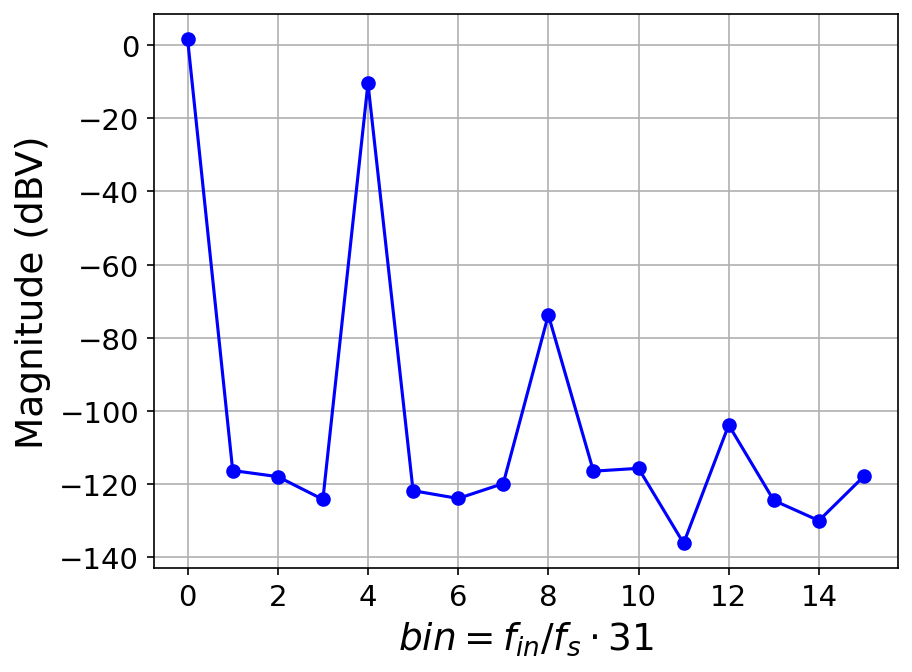

In [11]:
spec_dbv_out = compute_spectra(bins, vo, ndft)[2]

plt.plot(spec_dbv_out[3, :], "b-o")
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("Magnitude (dBV)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.ylim(25, 72)
plt.grid(True)
plt.show()
